In [6]:
# read data from csv
x_train, y_train = [], []
for line in open("lr.csv"):
    point = line.strip().split(",")
    x_train.append(float(point[0]))
    y_train.append(float(point[1]))
size = len(x_train)
print((x_train, y_train, size))

([10.0, 20.0, 40.0, 60.0, 80.0], [55.0, 80.0, 100.0, 120.0, 150.0], 5)


In [26]:
def predict(x, w):
    return w[0] + w[1] * x


def loss(x, y, w):
    return sum(((predict(x_i, w) - y_i) ** 2 / size for x_i, y_i in zip(x, y)))


def grad_descent(x, y, w, lr):

    fopd_0 = 2 * sum(((predict(x_i, w) - y_i) / size for x_i, y_i in zip(x, y)))
    fopd_1 = 2 * sum((x_i * ((predict(x_i, w) - y_i) / size) for x_i, y_i in zip(x, y)))

    w0 = w[0] - lr * fopd_0
    w1 = w[1] - lr * fopd_1

    return w0, w1


def training_loop(weight, lr, epsilon):
    time = 0
    y_pred = [predict(x_i, weight) for x_i in x_train]
    current_loss = loss(y_pred, y_train, weight)
    delta = 10

    while delta > epsilon:
        weight = grad_descent(x_train, y_train, weight, lr)
        y_pred = [predict(x_i, weight) for x_i in x_train]
        delta = abs(current_loss - loss(y_pred, y_train, weight))

        current_loss = loss(y_pred, y_train, weight)
        time += 1
        # print(time, weight, current_loss, delta)
    return time, weight, current_loss

In [28]:
lr = 2.5*1e-4
weight: tuple[float, float] = (5.0, 2.0)
epsilon = 1e-6

time, weight, final_loss = training_loop(weight, lr, epsilon)
print(f"Converged in {time} iterations with final weight {weight} and loss {final_loss}")

Converged in 96344 iterations with final weight (47.98771292513566, 1.262196718006951) and loss 5636.464636021761


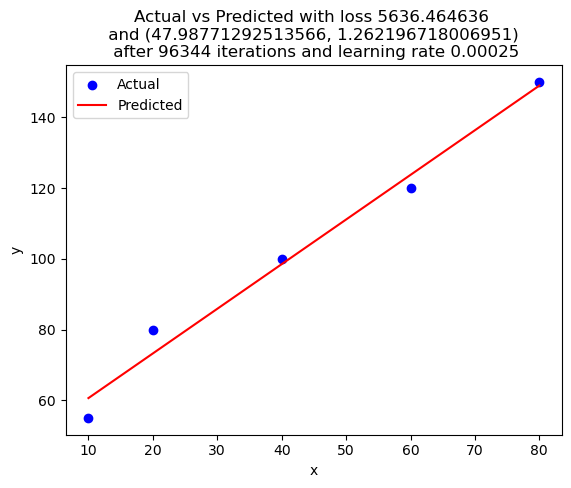

In [ ]:
import matplotlib.pyplot as plt

y_pred = [predict(x_i, weight) for x_i in x_train]

plt.scatter(x_train, y_train, color="blue", label="Actual")
plt.plot(x_train, y_pred, color="red", label="Predicted")
plt.xlabel("x")
plt.ylabel("y")
plt.title(f"Actual vs Predicted with loss {final_loss:.6f} \n and {weight} \n after {time} iterations and learning rate {lr}")
plt.legend()
plt.show()

Converged in 13900697 iterations with final weight (47.96482336196314, 1.262594019378453) and loss 5638.301870378607
Converged in 3373896 iterations with final weight (47.98320678075936, 1.2622749325769451) and loss 5636.82625124216
Converged in 1814827 iterations with final weight (47.98550572068511, 1.2622350291511515) and loss 5636.641758417686
Converged in 422351 iterations with final weight (47.98734504528652, 1.2622031034135888) and loss 5636.494156838383
Converged in 223962 iterations with final weight (47.987574970045316, 1.2621991125369902) and loss 5636.475706312545
Converged in 118373 iterations with final weight (47.98768993480675, 1.2621971170573456) and loss 5636.466480892533
Converged in 96344 iterations with final weight (47.98771292513566, 1.262196718006951) and loss 5636.464636021761
Converged in 81407 iterations with final weight (47.98772825303465, 1.2621964519557713) and loss 5636.463406027134
Converged in 62381 iterations with final weight (47.98774741634359, 1.26

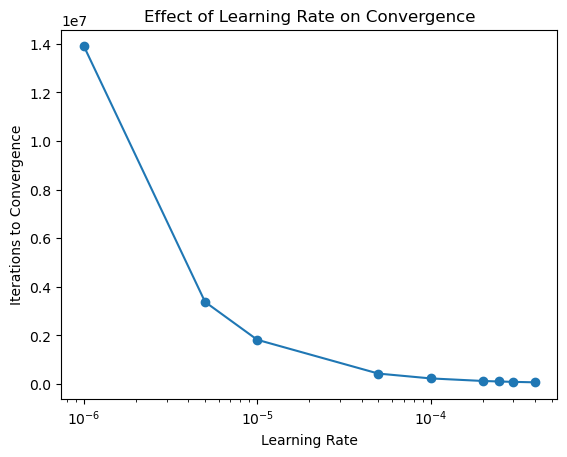

In [20]:
lrs = [1e-6,5*1e-6, 1e-5, 5 * 1e-5, 1e-4, 2 * 1e-4, 2.5 * 1e-4, 3 * 1e-4, 4 * 1e-4]

epsilon = 1e-6
data = []
for lr in lrs:
    weight: tuple[float, float] = (5.0, 2.0)
    time, weight, final_loss = training_loop(weight, lr, epsilon)
    print(
        f"Converged in {time} iterations with final weight {weight} and loss {final_loss}"
    )
    data.append((lr, time))
    
plt.plot([d[0] for d in data], [d[1] for d in data], marker="o")
plt.xlabel("Learning Rate")
plt.ylabel("Iterations to Convergence")
plt.title("Effect of Learning Rate on Convergence")
plt.xscale("log")
plt.show()